cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/meetnagadia/apple-stock-price-from-19802021
License(s): ODbL-1.0
apple-stock-price-from-19802021.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  apple-stock-price-from-19802021.zip
replace AAPL.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:          Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0069
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.3720e-04
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.1581e-04
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.8249e-04
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.8052e-04
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step


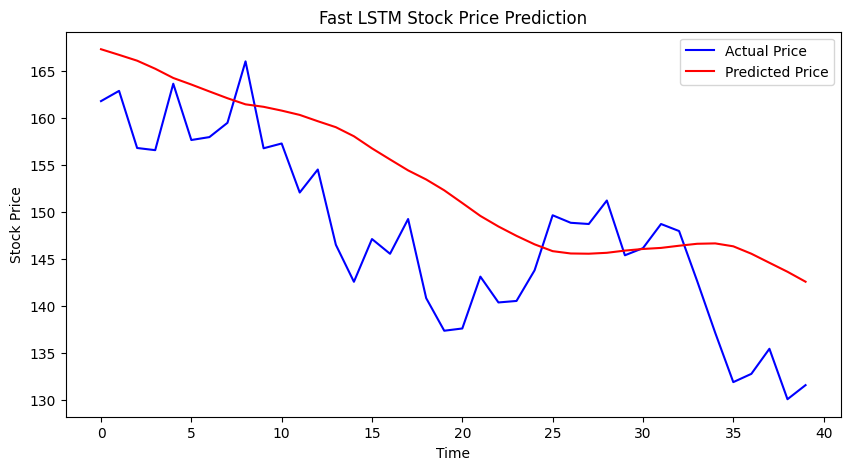

In [2]:
# ============================================
# FAST LSTM STOCK PRICE PREDICTION
# Optimized for College Lab / Colab
# ============================================


# ============================================
# STEP 1: Setup Kaggle API
# ============================================

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# ============================================
# STEP 2: Download Dataset
# ============================================

!kaggle datasets download -d meetnagadia/apple-stock-price-from-19802021


# ============================================
# STEP 3: Unzip Dataset
# ============================================

!unzip apple-stock-price-from-19802021.zip


# ============================================
# STEP 4: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM
)


# ============================================
# STEP 5: Load Dataset
# ============================================

dataset = pd.read_csv("AAPL.csv")

print(dataset.head())


# ============================================
# STEP 6: Keep Smaller Dataset
# (FASTER TRAINING)
# ============================================

dataset = dataset.tail(2000)


# ============================================
# STEP 7: Select Closing Prices
# ============================================

dataset['Close'] = pd.to_numeric(
    dataset['Close'],
    errors='coerce'
)

dataset.dropna(
    subset=['Close'],
    inplace=True
)


data = dataset['Close'].values

data = data.reshape(-1, 1)


# ============================================
# STEP 8: Normalize Data
# ============================================

scaler = MinMaxScaler(
    feature_range=(0,1)
)

scaled_data = scaler.fit_transform(data)


# ============================================
# STEP 9: Create Training Data
# ============================================

X_train = []

y_train = []

time_step = 20

for i in range(time_step, len(scaled_data)):

    X_train.append(
        scaled_data[i-time_step:i, 0] #Stores previous 20 prices.
    )

    y_train.append(
        scaled_data[i, 0] #Stores current price(day 21).
    )


X_train = np.array(X_train)

y_train = np.array(y_train)


# ============================================
# STEP 10: Reshape for LSTM (samples, time_steps, features)
# ============================================

X_train = np.reshape(

    X_train,

    (
        X_train.shape[0],
        X_train.shape[1],
        1
    )
)


# ============================================
# STEP 11: Build LSTM Model
# ============================================

model = Sequential()

model.add(

    LSTM(
        units=25,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            1
        )
    )
)

model.add(
    LSTM(units=25)
)

model.add(
    Dense(units=1)
)


# ============================================
# STEP 12: Compile Model
# ============================================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


# ============================================
# STEP 13: Train Model
# ============================================

model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32
)


# ============================================
# STEP 14: Prepare Test Data
# ============================================

test_data = scaled_data[-60:]

X_test = []

y_test = data[-40:]


for i in range(time_step, len(test_data)):

    X_test.append(
        test_data[i-time_step:i, 0]
    )


X_test = np.array(X_test)

X_test = np.reshape(

    X_test,

    (
        X_test.shape[0],
        X_test.shape[1],
        1
    )
)


# ============================================
# STEP 15: Prediction
# ============================================

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(
    predictions
)


# ============================================
# STEP 16: Plot Results
# ============================================

plt.figure(figsize=(10,5))

plt.plot(
    y_test,
    color='blue',
    label='Actual Price'
)

plt.plot(
    predictions,
    color='red',
    label='Predicted Price'
)

plt.title('Fast LSTM Stock Price Prediction')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.show()